In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df_play_by_play = pd.read_csv('../csv/cleaned/Proyecto Final DAPT10play_by_play_clean.csv')

In [4]:
df_top20= pd.read_csv('../eda/top8_roi_nba_2004_2023.csv')

In [5]:
df_game= pd.read_csv('../csv/cleaned/game_clean.csv')

In [6]:
def calcular_promedio_pts_pintura(df_play, df_top20):
    # Identificamos columna de ID en top 20
    col_id_top20 = [col for col in df_top20.columns if 'id' in col.lower()][0]
    lista_ids = df_top20[col_id_top20].unique()
    
    # Filtramos solo jugadas de pintura (Dunk, Layup, etc.)
    keywords = 'Dunk|Layup|Hook|Tip|Bank Shot|Driving'
    mask_pintura = (
        (df_play['eventmsgtype'] == 1) & 
        (df_play['event_description'].str.contains(keywords, case=False, na=False)) &
        (df_play['player1_id'].isin(lista_ids))
    )
    
    # Sumamos puntos TOTALES por cada JUEGO y cada JUGADOR
    df_por_juego = df_play[mask_pintura].copy()
    df_por_juego['pts_paint'] = 2
    
    puntos_partido = (
        df_por_juego.groupby(['game_id', 'player1_id'])['pts_paint']
        .sum()
        .reset_index()
    )
    
    # Calculamos el promedio final por jugador
    df_promedios = (
        puntos_partido.groupby('player1_id')['pts_paint']
        .mean()
        .reset_index()
    )
    
    # Formateamos y ordenamos
    df_promedios.columns = ['player1_id', 'avg_pts_paint']
    df_promedios = df_promedios.sort_values(by='avg_pts_paint', ascending=False)
    
    return df_promedios

df_avg_pintura = calcular_promedio_pts_pintura(df_play_by_play, df_top20)

In [7]:
df_avg_pintura.to_csv('top8_pts_pintura_nba_2004_2023.csv', index=False)

In [8]:
stats_pts_pintura= df_avg_pintura['avg_pts_paint'].mean().astype(int)
print(stats_pts_pintura)

7


In [10]:
def calcular_eficiencia_tiro_top20(df_play, df_top20):
    # Identificamos ID del jugador en el Top 20
    col_id = [c for c in df_top20.columns if 'id' in c.lower()][0]
    lista_ids = df_top20[col_id].unique()
    
    # Filtramos eventos de tiro (1=Anotado, 2=Fallado) para los jugadores
    # player1_id es el principal
    mask_tiros = (df_play['eventmsgtype'].isin([1, 2])) & (df_play['player1_id'].isin(lista_ids))
    df_tiros = df_play[mask_tiros].copy()
    
    # Clasificaos FGM y FGA
    # FGM: Tiros de campo convertidos
    df_tiros['fgm'] = np.where(df_tiros['eventmsgtype'] == 1, 1, 0)
    # FGA: Tiros de campo intentados (cualquier tiro cuenta como intento)
    df_tiros['fga'] = 1
    
    # Agrupamos por Partido y Jugador para tener totales por juego
    stats_juego = df_tiros.groupby(['game_id', 'player1_id'])[['fgm', 'fga']].sum().reset_index()
    
    # Calculamos el porcentaje por juego ($fgm / fga$)
    stats_juego['fg_pct'] = (stats_juego['fgm'] / stats_juego['fga']) * 100
    
    # Promediamos los resultados de todos los juegos para cada jugador
    df_final = stats_juego.groupby('player1_id')[['fgm', 'fga', 'fg_pct']].mean().reset_index()
    
    # Redondeamos
    df_final['fg_pct'] = df_final['fg_pct'].round(1)
    
    return df_final.sort_values(by='fg_pct', ascending=False)

df_eficiencia = calcular_eficiencia_tiro_top20(df_play_by_play, df_top20)

In [11]:
df_eficiencia.to_csv('top8_eficiencia_nba_2004_2023.csv', index=False)

In [12]:
stats_eficiencia= df_eficiencia['fg_pct'].mean()
print(stats_eficiencia)

48.1125


In [14]:
def calcular_inteligencia_juego_top20(df_play, df_top20):
    # Identificamos ID del jugador
    col_id = [c for c in df_top20.columns if 'id' in c.lower()][0]
    lista_ids = df_top20[col_id].unique()

    # --- PARTE A: ASISTENCIAS (El jugador es player2_id en un tiro anotado) ---
    mask_ast = (df_play['eventmsgtype'] == 1) & (df_play['player2_id'].isin(lista_ids))
    df_ast = df_play[mask_ast].copy()
    df_ast['ast_count'] = 1
    
    ast_juego = df_ast.groupby(['game_id', 'player2_id'])['ast_count'].sum().reset_index()
    ast_juego.columns = ['game_id', 'player1_id', 'ast'] # Normalizamos nombre para unir

    # --- PARTE B: PÉRDIDAS (El jugador es player1_id en eventmsgtype 5) ---
    mask_tov = (df_play['eventmsgtype'] == 5) & (df_play['player1_id'].isin(lista_ids))
    df_tov = df_play[mask_tov].copy()
    df_tov['tov_count'] = 1
    
    tov_juego = df_tov.groupby(['game_id', 'player1_id'])['tov_count'].sum().reset_index()
    tov_juego.columns = ['game_id', 'player1_id', 'tov']

    # --- PARTE C: UNIMOS Y CALCULAMOS RATIO ---
    # Asistencias y pérdidas por juego
    stats_juego = pd.merge(ast_juego, tov_juego, on=['game_id', 'player1_id'], how='outer').fillna(0)
    
    # Calculamos el Ratio (evitando división por cero con np.where)
    stats_juego['ast_tov_ratio'] = np.where(
        stats_juego['tov'] == 0, 
        stats_juego['ast'], # Si no hay pérdidas, el ratio es igual a las asistencias
        stats_juego['ast'] / stats_juego['tov']
    )

    # Promediamos resultados de todos los juegos
    df_final = stats_juego.groupby('player1_id')[['ast', 'tov', 'ast_tov_ratio']].mean().reset_index()
    
    # Redondeo
    df_final = df_final.round(2)
    
    return df_final.sort_values(by='ast_tov_ratio', ascending=False)

df_asist_ratio = calcular_inteligencia_juego_top20(df_play_by_play, df_top20)

In [15]:
stats_asist_ratio= df_asist_ratio['ast_tov_ratio'].mean().astype(int)
print(stats_asist_ratio)

2


In [17]:
stats_asist_totales= df_asist_ratio['ast'].mean().astype(int)
print(stats_asist_totales)

5


In [19]:
df_asist_ratio.to_csv('top8_asist_ratio_nba_2004_2023.csv', index=False)

In [20]:
def calcular_pts_off_tov_top20(df_play, df_top20):
    # Identificamos ID del jugador en el Top 20
    col_id = [c for c in df_top20.columns if 'id' in c.lower()][0]
    lista_ids = df_top20[col_id].unique()

    # Ordenamos cronológicamente por juego y número de evento
    df_sorted = df_play.sort_values(['game_id', 'eventnum']).copy()

    # CREAMOS LAS COLUMNAS DE REFERENCIA
    # Obtenemos el tipo de evento anterior (buscamos el 5 = Pérdida)
    df_sorted['prev_event_type'] = df_sorted.groupby('game_id')['eventmsgtype'].shift(1)
    # Obtenemos el equipo del evento anterior (el equipo que perdió el balón)
    df_sorted['prev_team_id'] = df_sorted.groupby('game_id')['player1_team_id'].shift(1)

    # FILTRAMOS: Solo puntos (type 1) tras pérdida rival (type 5 de otro equipo)
    mask_off_tov = (
        (df_sorted['eventmsgtype'] == 1) &                # Jugador anotó
        (df_sorted['prev_event_type'] == 5) &             # Evento previo fue pérdida
        (df_sorted['player1_id'].isin(lista_ids)) &       # Es uno de tus 20 jugadores
        (df_sorted['player1_team_id'] != df_sorted['prev_team_id']) # EQUIPOS DISTINTOS
    )
    
    df_scores = df_sorted[mask_off_tov].copy()

    # ASIGNAMOS PUNTOS (3 si la descripción dice 3PT, si no 2)
    df_scores['pts_val'] = np.where(
        df_scores['event_description'].str.contains('3PT', case=False, na=False), 3, 2
    )

    # AGRUPAMOS por juego y luego sacar el promedio por jugador
    stats_juego = df_scores.groupby(['game_id', 'player1_id'])['pts_val'].sum().reset_index()
    
    df_final = stats_juego.groupby('player1_id')['pts_val'].mean().reset_index()
    df_final.columns = ['player1_id', 'avg_pts_off_tov']
    
    return df_final.round(2).sort_values(by='avg_pts_off_tov', ascending=False)

df_off_tov = calcular_pts_off_tov_top20(df_play_by_play, df_top20)

In [21]:
stats_off_tov= df_off_tov['avg_pts_off_tov'].mean().astype(int)
print(stats_off_tov)

3


In [22]:
df_off_tov.to_csv('top8_perdidas_rivales_nba_2004_2023.csv', index=False)

In [23]:
def calcular_pts_2nd_chance_top20(df_play, df_top20):
    # Identificamos ID del jugador en el Top 20
    col_id = [c for c in df_top20.columns if 'id' in c.lower()][0]
    lista_ids = df_top20[col_id].unique()

    # Ordenamos cronológicamente para no perder la secuencia
    df_sorted = df_play.sort_values(['game_id', 'eventnum']).copy()

    # Creamos columnas de referencia del evento anterior
    # Tipo de evento anterior (buscamos 4 = Rebote)
    df_sorted['prev_event_type'] = df_sorted.groupby('game_id')['eventmsgtype'].shift(1)
    # Equipo que capturó el rebote
    df_sorted['prev_team_id'] = df_sorted.groupby('game_id')['player1_team_id'].shift(1)
    # Descripción para confirmar que fue ofensivo (opcional pero recomendado)
    df_sorted['prev_desc'] = df_sorted.groupby('game_id')['event_description'].shift(1)

    # FILTRAMPS: 
    # - El jugador anotó (type 1)
    # - El evento anterior fue un Rebote (type 4)
    # - El equipo del rebote es el MISMO que el que anota (Rebote Ofensivo)
    mask_2nd_chance = (
        (df_sorted['eventmsgtype'] == 1) & 
        (df_sorted['prev_event_type'] == 4) &
        (df_sorted['player1_id'].isin(lista_ids)) &
        (df_sorted['player1_team_id'] == df_sorted['prev_team_id'])
    )
    
    df_2nd = df_sorted[mask_2nd_chance].copy()

    # Asignamos puntos (3 si es Triple, 2 si es Doble)
    df_2nd['pts_val'] = np.where(
        df_2nd['event_description'].str.contains('3PT', case=False, na=False), 3, 2
    )

    # Agrupamos por juego y sacar promedio
    stats_juego = df_2nd.groupby(['game_id', 'player1_id'])['pts_val'].sum().reset_index()
    
    df_final = stats_juego.groupby('player1_id')['pts_val'].mean().reset_index()
    df_final.columns = ['player1_id', 'avg_pts_2nd_chance']
    
    return df_final.round(2).sort_values(by='avg_pts_2nd_chance', ascending=False)

df_2nd_chance = calcular_pts_2nd_chance_top20(df_play_by_play, df_top20)

In [24]:
stats_2nd_chance=df_2nd_chance['avg_pts_2nd_chance'].mean().astype(int)
print(stats_2nd_chance)

7


In [25]:
df_2nd_chance.to_csv('top8_pts_2nd_chance_nba_2004_2023.csv', index=False)

In [27]:
def calcular_pts_promedio_top20(df_play, df_top20):
    # Identifiamos ID del jugador
    col_id = [c for c in df_top20.columns if 'id' in c.lower()][0]
    lista_ids = df_top20[col_id].unique()

    # Filtramos eventos que suman puntos (1=Tiro Campo, 3=Tiro Libre)
    mask_puntos = (df_play['eventmsgtype'].isin([1, 3])) & (df_play['player1_id'].isin(lista_ids))
    df_puntos = df_play[mask_puntos].copy()

    # Asignamos el valor real de cada punto
    # Si es tiro libre (type 3), vale 1. Si es de campo (type 1), buscamos '3PT'
    def asignar_valor(row):
        if row['eventmsgtype'] == 3:
            return 1
        elif '3PT' in str(row['event_description']):
            return 3
        else:
            return 2

    df_puntos['pts_ganados'] = df_puntos.apply(asignar_valor, axis=1)

    # Agrupamos por juego y jugador para tener el total de cada partido
    pts_por_juego = df_puntos.groupby(['game_id', 'player1_id'])['pts_ganados'].sum().reset_index()

    # Calculamos el promedio de esos totales
    df_final = pts_por_juego.groupby('player1_id')['pts_ganados'].mean().reset_index()
    df_final.columns = ['player1_id', 'avg_pts_totales']
    
    # Redondeamos
    df_final['avg_pts_totales'] = df_final['avg_pts_totales'].round(1)

    return df_final.sort_values(by='avg_pts_totales', ascending=False)

df_pts_totales = calcular_pts_promedio_top20(df_play_by_play, df_top20)

In [28]:
stats_pts_totales=df_pts_totales['avg_pts_totales'].mean().astype(int)
print(stats_pts_totales)

24


In [29]:
df_pts_totales.to_csv('top8_pts_totales_nba_2004_2023.csv', index=False)

In [9]:
df_avg_pintura.describe()

,player1_id,avg_pts_paint
count,8.000000,8.000000
mean,189810.375000,7.849096
std,35849.535809,2.948539
min,101108.000000,4.295378
25%,201736.750000,6.251180
50%,202317.000000,7.017905
75%,203077.250000,8.438337
max,203507.000000,13.194070


In [13]:
df_eficiencia.describe()

,player1_id,fgm,fga,fg_pct
count,8.000000,8.000000,8.000000,8.000000
mean,189810.375000,8.101824,16.754185,48.112500
std,35849.535809,1.066642,2.033783,3.504461
min,101108.000000,6.394693,13.518242,43.500000
25%,201736.750000,7.287494,15.386966,45.750000
50%,202317.000000,8.328530,17.071988,48.500000
75%,203077.250000,8.742093,18.272769,50.575000
max,203507.000000,9.417485,19.075639,52.300000


In [16]:
df_asist_ratio.describe()

,player1_id,ast,tov,ast_tov_ratio
count,8.000000,8.000000,8.000000,8.000000
mean,189810.375000,5.513750,2.778750,2.648750
std,35849.535809,2.226874,0.630157,1.126428
min,101108.000000,2.560000,1.810000,1.640000
25%,201736.750000,4.017500,2.345000,1.990000
50%,202317.000000,5.585000,2.950000,2.275000
75%,203077.250000,6.632500,3.147500,2.850000
max,203507.000000,9.340000,3.690000,5.160000


In [30]:
df_off_tov.describe()

,player1_id,avg_pts_off_tov
count,8.000000,8.000000
mean,189810.375000,3.426250
std,35849.535809,0.304722
min,101108.000000,3.030000
25%,201736.750000,3.215000
50%,202317.000000,3.410000
75%,203077.250000,3.572500
max,203507.000000,4.010000


In [31]:
df_2nd_chance.describe()

,player1_id,avg_pts_2nd_chance
count,8.000000,8.000000
mean,189810.375000,7.083750
std,35849.535809,0.680797
min,101108.000000,5.750000
25%,201736.750000,6.847500
50%,202317.000000,7.290000
75%,203077.250000,7.540000
max,203507.000000,7.810000


In [32]:
df_pts_totales.describe()

,player1_id,avg_pts_totales
count,8.000000,8.000000
mean,189810.375000,24.712500
std,35849.535809,3.184981
min,101108.000000,18.600000
25%,201736.750000,24.300000
50%,202317.000000,25.500000
75%,203077.250000,26.475000
max,203507.000000,28.400000


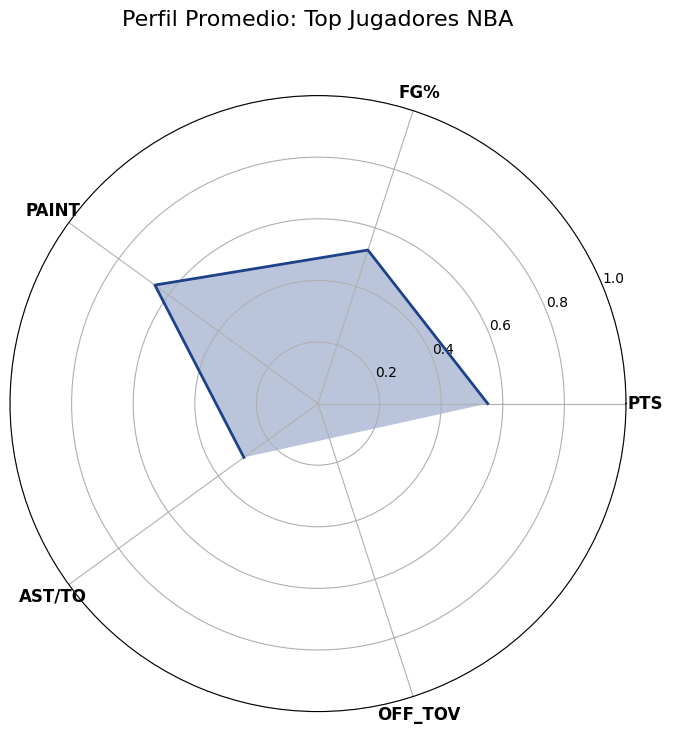

In [42]:
# Definimos las 5 métricas que elegimos
categorias = ['PTS', 'FG%', 'PAINT', 'AST/TO', 'OFF_TOV']

# Variables
variables_stats = [
    stats_pts_totales,  # 24.7
    stats_eficiencia,   # 48.11
    stats_pts_pintura,  # 7.84
    stats_asist_ratio,  # 2.64
    stats_off_tov        # 3.42
]

# Límites (Min/Max de cada describe)
limites = {
    'PTS':      {'min': 18.6,  'max': 28.4},    # Min y Max del Top 8
    'FG%':      {'min': 43.5,  'max': 52.3},    # Min y Max del Top 8
    'PAINT':    {'min': 4.29,  'max': 8.43},    # Ajustado: Usamos el 75% o el max cercano (evitamos el 13.19 que era un outlier)
    'AST/TO':   {'min': 1.64,  'max': 2.85},    # Ajustado: Usamos el 75% (2.85) para que el promedio (2.64) luzca
    'OFF_TOV':  {'min': 3.03,  'max': 4.01}     # Min y Max del Top 8
}

# Normalización Min-Max aplicada a las variables
valores_norm = []
for i, cat in enumerate(categorias):
    v = variables_stats[i]
    v_min = limites[cat]['min']
    v_max = limites[cat]['max']
    
    # La fórmula de normalización:
    norm = (v - v_min) / (v_max - v_min)
    valores_norm.append(norm)

# Configuración visual del Radar
angles = [n / float(len(categorias)) * 2 * np.pi for n in range(len(categorias))]
valores_norm += valores_norm[:1]  # Cerramos círculo
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))


# Dibujamos ejes y etiquetas
plt.xticks(angles[:-1], categorias, color='black', size=12, fontweight='bold')

# Dibujamos el área del radar
ax.plot(angles, valores_norm, color='#1d428a', linewidth=2)
ax.fill(angles, valores_norm, color='#1d428a', alpha=0.3)

# Fijamos el límite de 0 a 1 (gracias a la normalización)
ax.set_ylim(0, 1)

plt.title('Perfil Promedio: Top Jugadores NBA', size=16, y=1.1)
plt.show()